### Data Loading

In [ ]:
import numpy as np
import struct
import os 

def load_idx(filename):
    with open(filename, 'rb') as f:
        # Read magic number
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        # Read the rest as unsigned bytes
        data = np.frombuffer(f.read(), dtype=np.uint8)
        # Reshape into (num, rows, cols)
        return data.reshape(num, rows, cols)

def load_labels(filename):
    with open(filename, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels


loc_path = os.getcwd()
x_train_full = load_idx(loc_path + '\\Datasets\\MNIST\\train-images.idx3-ubyte') / 255.0
y_train_full = load_labels(loc_path + '\\Datasets\\MNIST\\train-labels.idx1-ubyte')

x_test = load_idx(loc_path + '\\Datasets\\MNIST\\\\t10k-images.idx3-ubyte') / 255.0
y_test = load_labels(loc_path + '\\Datasets\\MNIST\\\\t10k-labels.idx1-ubyte')

x_train = x_train_full
y_train = y_train_full

### Optional Load a Saved Model

In [48]:
import os
import tensorflow as tf

model = None

def load_best_model():
    models_dir = os.path.join(loc_path, "Models")

    for path in os.listdir(models_dir):
        filepath = os.path.join(models_dir, path)
        if path.startswith("Mnist_Perceptron_Tensorflow"):
            model = tf.keras.models.load_model(filepath)
            print("Loaded motel at : " + filepath)
            return model
    print("No saved model found.")

load_model = False
if load_model:
    model = load_best_model()


### Model Creation

In this code in this first part with models.sequential we're creating the model architecture; the class sequential allows us to create a model where layers are created one after another  
like in a pipeline.

In the second part with model.compile we're setting other things related to optimization and evaluation.

In the final section, we observe the training of the model using model.fit() with the training dataset. This method automatically handles the entire training loop — including the forward pass, backward pass, and weight updates. Its output is a History object, which stores the evolution of metrics across epochs. The History object provides a dictionary accessible via .history, where the keys correspond to the loss and metrics defined in model.compile, and the values are lists showing how each metric changes over the course of training (e.g., loss and accuracy).

In [49]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
history = None

if not load_model:
    # Build and train the model
    model = models.Sequential([
        layers.Input(shape=(28, 28)), # Input layer for 28x28 images
        layers.Flatten(),  # Flatten 28x28 images into 784-dimensional vectors
        layers.Dense(128, activation='relu'), # Hidden layer with 128 neurons and ReLU activation
        layers.Dense(10, activation='softmax') # Output layer for 10 classes using softmax
    ])

    model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

    history = model.fit(x_train, y_train, epochs=5, batch_size=4)


Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7440 - loss: 0.8730
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9050 - loss: 0.3443
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9480 - loss: 0.2046
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9640 - loss: 0.1380
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9870 - loss: 0.0768


### Model Evaluation

The method model.evaluate returns the loss and the accuracy of a model on the test set

Usually if training metrics and test metrics are very differents it means you have a bit/a lot of overfitting

In [50]:
# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {accuracy*100:.2f}%")
print(f"Test loss: {loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8691 - loss: 0.4445
Test accuracy: 86.91%
Test loss: 0.4445


### Model Summary

After defining the network, you can visualize its structure (layers, input/output shapes) and inspect its parameters (weight matrices and bias vectors). This helps you analyze the model’s logic and estimate its complexity (the number of parameters that must be optimized during training).
In Keras, the summary() method of the tf.keras.Model (or tf.keras.Sequential) class prints a table containing: layer name, output shape, and number of parameters (trainable and non-trainable). It is ideal for quickly checking the architecture.

In [51]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

### Saving The Model

In [52]:
def save_model_if_better():
    model_power = int(accuracy + np.log(model.count_params()))
    file_exists = False
    for path in os.listdir(loc_path + "\\Models"):
        if path.startswith("Mnist_Perceptron_Tensorflow"):
            file_exists = True
            string_parts = path.split("_")
            old_model_power = int(string_parts[-2])
            if model_power > old_model_power:
                model.save(loc_path + f"\\Models\\Mnist_Perceptron_Tensorflow_{model_power}_.keras")
                print(f"New model saved with power {model_power}")
    if not file_exists:
        model.save(loc_path + f"\\Models\\Mnist_Perceptron_Tensorflow_{model_power}_.keras")
        print(f"New model saved with power {model_power}")

if not load_model:
    save_model_if_better()


### Visualizing the Accuracy Rise

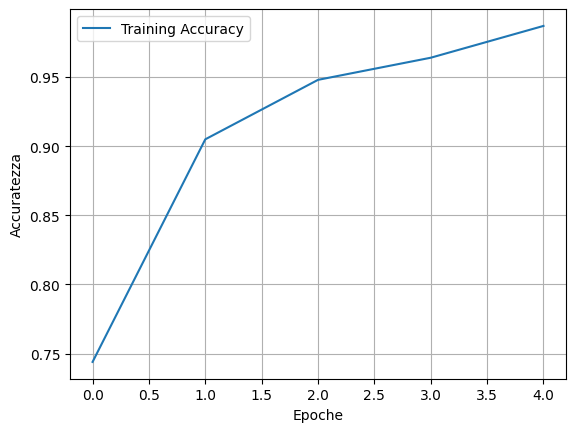

In [53]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')
plt.legend()
plt.grid(True)
plt.show()

### Visualizing Loss Descent

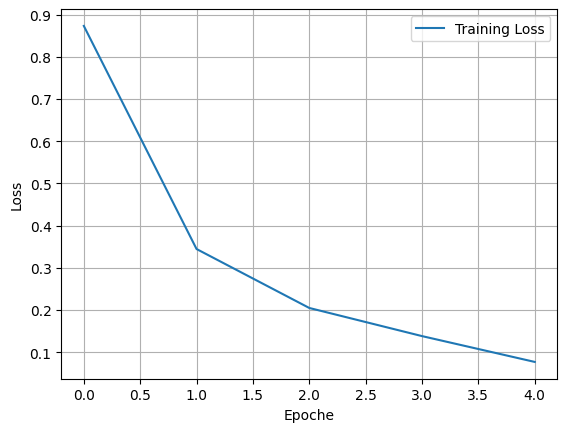

In [54]:
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Visualizing The Model Structure(needs graphviz and pydot)

In [55]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model_structure.png', show_shapes=True, show_layer_names=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


### 

### Ses

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


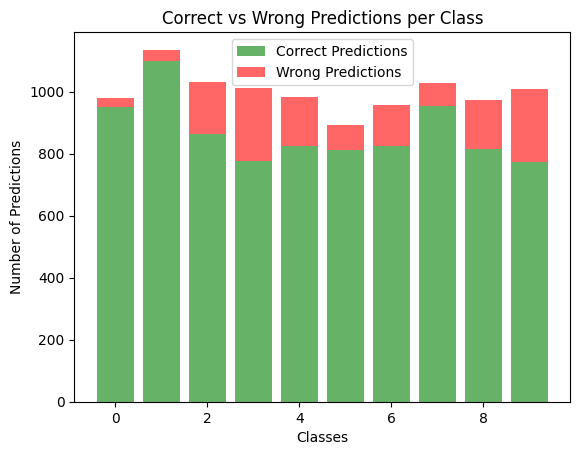

<Figure size 1200x1200 with 0 Axes>

In [61]:
import matplotlib.pyplot as plt

predicted_probs_x_test = model.predict(x_test)
predicted_classes = np.argmax(predicted_probs_x_test, axis=1)

classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
correct_predictions_for_class = [0,0,0,0,0,0,0,0,0,0]
wrong_predictions_for_class = [0,0,0,0,0,0,0,0,0,0]

for y_true, y_pred in zip(y_test, predicted_classes):
    if y_true == y_pred:
        correct_predictions_for_class[y_true] += 1
    else:
        wrong_predictions_for_class[y_true] += 1

plt.bar(classes, correct_predictions_for_class, color='g', alpha=0.6, label='Correct Predictions')
plt.bar(classes, wrong_predictions_for_class, bottom=correct_predictions_for_class, color='r', alpha=0.6, label='Wrong Predictions')
plt.xlabel('Classes')
plt.ylabel('Number of Predictions')
plt.title('Correct vs Wrong Predictions per Class')
plt.legend()
plt.figure(figsize=(12,12))
plt.show()
